<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/Lab1_Perceptron_using_NumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 1 - Simulate a Perceptron using NumPy

Builds a perceptron completely from scratch. No scikit-learn, no TensorFlow, just NumPy - and trains it on logic gates to actually watch the perceptron learning rule update weights step by step.

**Pipeline:** inputs → weighted sum + bias → step activation → compare with target → update weights → repeat for every sample, every epoch.

## What a perceptron actually is

A perceptron is the smallest possible unit of a neural network - one artificial neuron. It takes in some inputs, gives each one an importance (a weight), adds them up along with a bias, and makes a single yes/no decision based on whether that sum crosses zero. That's it, no hidden layers, no backpropagation, just one neuron deciding a single boundary line that splits the input space into two classes.

The learning part is the interesting bit: the perceptron doesn't know the right weights in advance. It starts at zero and nudges its own weights every time it gets an answer wrong, until if the data actually allows it, it settles on weights that get everything right.

In [ ]:
# 1. Simulate a Perceptron using NumPy
import numpy as np
import matplotlib.pyplot as plt

# Step activation function - the perceptron's decision rule
def step_function(x):
    return 1 if x >= 0 else 0

# Perceptron class
class Perceptron:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.zeros(input_size)
        self.bias = 0.0
        self.lr = learning_rate

    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return step_function(z)

    def train(self, X, y, epochs=10):
        errors_per_epoch = []
        for epoch in range(epochs):
            total_errors = 0
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                error = target - prediction
                self.weights += self.lr * error * xi
                self.bias += self.lr * error
                total_errors += int(error != 0)
            errors_per_epoch.append(total_errors)
        return errors_per_epoch

### In layman terms - what's actually happening in `train()`

Every input first gets multiplied by its own weight and summed up along with the bias - that's just `z = w·x + b`. That single number `z` is passed through the step function, which is really just asking "is this positive or not" and spits out a hard 0 or 1.

Then we compare that output to what the answer should actually have been - that's `error = target - prediction`. If the perceptron already got it right, error is 0 and nothing moves. If it's wrong, the weights get nudged in whatever direction would have made *that specific input* correct (`weights += lr * error * xi`). The bias moves the same way, just without an input attached to it, since it isn't tied to any particular feature.

We do this one input at a time, for every input, for several epochs, until the weights settle into values where the whole training set gives zero error - or until it becomes clear that's never going to happen (more on that below).

### Full pipeline

```
Input x = [x1, x2]
        ↓
Weighted sum: z = w1*x1 + w2*x2 + b
        ↓
Step function: output = 1 if z >= 0 else 0
        ↓
Compare with actual target
        ↓
error = target - output
        ↓
Update: w = w + lr * error * x
        b = b + lr * error
        ↓
Repeat for every sample → repeat for every epoch
```

## Training on AND

Same dataset the practical asks for - the 4 possible 2-bit inputs, labelled with the AND truth table.

In [ ]:
# Training data for AND gate
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

# Train the perceptron
p = Perceptron(input_size=2)
errors_per_epoch = p.train(X, y, epochs=10)

print("Errors per epoch:", errors_per_epoch)
print("\nPredictions:")
for xi in X:
    print(f"Input: {xi}, Output: {p.predict(xi)}")
print(f"\nFinal weights: {p.weights}, bias: {p.bias:.2f}")

Errors per epoch: [2, 3, 3, 0, 0, 0, 0, 0, 0, 0]

Predictions:
Input: [0 0], Output: 0
Input: [0 1], Output: 0
Input: [1 0], Output: 0
Input: [1 1], Output: 1

Final weights: [0.2 0.1], bias: -0.20


#### Observation
Errors drop 2 → 3 → 3 → 0 and then stay at 0 for the rest of training, so the perceptron actually finds a working boundary by epoch 4 - the remaining 6 epochs are just confirming it stays there. Final predictions (0, 0, 0, 1) match the AND truth table exactly.

## Does it generalize? Testing on OR and XOR

The practical only asks for AND, but a perceptron is supposed to work on *any* logic gate as long as it's linearly separable, meaning one straight line can put every 0 on one side and every 1 on the other. AND and OR both qualify. XOR does not, and I wanted to actually see that failure rather than just take it on faith.

In [ ]:
gates = {
    "AND": np.array([0,0,0,1]),
    "OR":  np.array([0,1,1,1]),
    "XOR": np.array([0,1,1,0]),
}

results = {}
for name, y_gate in gates.items():
    epochs = 10 if name != "XOR" else 20
    model = Perceptron(input_size=2)
    errs = model.train(X, y_gate, epochs=epochs)
    results[name] = (model, errs)
    print(f"--- {name} ---")
    print("errors per epoch:", errs)
    for xi in X:
        print(f"Input: {xi}, Output: {model.predict(xi)}")
    print(f"weights: {model.weights}, bias: {model.bias:.2f}\n")

--- AND ---
errors per epoch: [2, 3, 3, 0, 0, 0, 0, 0, 0, 0]
Input: [0 0], Output: 0
Input: [0 1], Output: 0
Input: [1 0], Output: 0
Input: [1 1], Output: 1
weights: [0.2 0.1], bias: -0.20

--- OR ---
errors per epoch: [2, 2, 1, 0, 0, 0, 0, 0, 0, 0]
Input: [0 0], Output: 0
Input: [0 1], Output: 1
Input: [1 0], Output: 1
Input: [1 1], Output: 1
weights: [0.1 0.1], bias: -0.10

--- XOR ---
errors per epoch: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Input: [0 0], Output: 1
Input: [0 1], Output: 1
Input: [1 0], Output: 0
Input: [1 1], Output: 0
weights: [-0.1  0. ], bias: 0.00



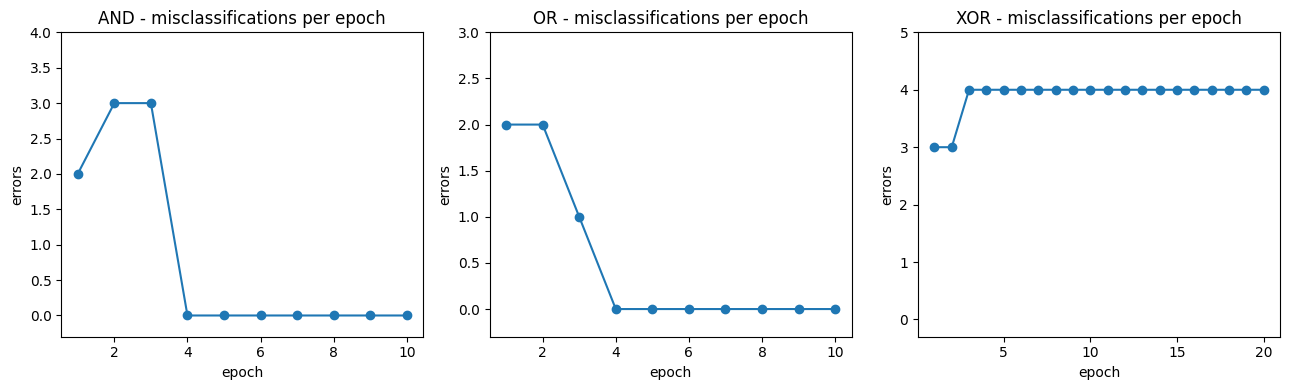

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, gates):
    model, errs = results[name]
    ax.plot(range(1, len(errs) + 1), errs, marker='o')
    ax.set_title(f"{name} - misclassifications per epoch")
    ax.set_xlabel("epoch")
    ax.set_ylabel("errors")
    ax.set_ylim(-0.3, max(errs) + 1)
plt.tight_layout()
plt.show()

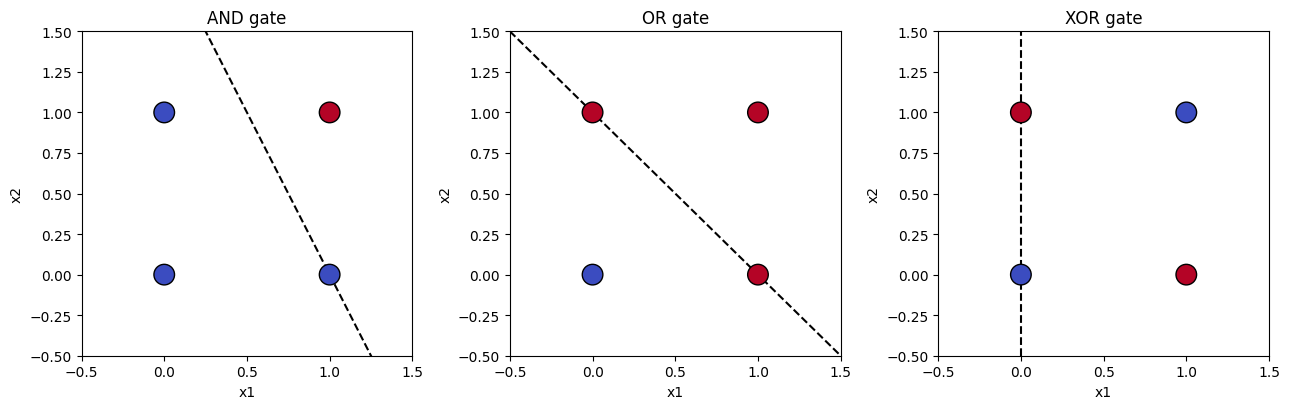

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
xs = np.linspace(-0.5, 1.5, 200)
for ax, name in zip(axes, gates):
    model, _ = results[name]
    y_gate = gates[name]
    if abs(model.weights[1]) > 1e-9:
        ys = -(model.weights[0] * xs + model.bias) / model.weights[1]
        ax.plot(xs, ys, 'k--', label='decision boundary')
    elif abs(model.weights[0]) > 1e-9:
        ax.axvline(-model.bias / model.weights[0], color='k', linestyle='--', label='decision boundary')
    ax.scatter(X[:, 0], X[:, 1], c=y_gate, cmap='coolwarm', s=220, edgecolor='k', zorder=5)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"{name} gate")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout()
plt.show()

### Personal notes. Why XOR breaks it

Looking at the plots: AND and OR both settle at 0 errors within 3-4 epochs, and the decision-boundary plot shows exactly why, one straight line cleanly separates the red point(s) from the blue ones in both cases. XOR's error count never reaches 0, it oscillates between 3 and 4 and just stays there no matter how many more epochs I give it (ran 20 here, it would do the same at 200).

The XOR boundary plot makes the reason obvious - the two "1" points and two "0" points sit diagonally opposite each other, so no single straight line can have both 1s on one side and both 0s on the other. The perceptron isn't failing because of a bug or a bad learning rate, it's structurally incapable of representing this function, full stop. This is exactly the historical limitation that pushed neural networks toward stacking multiple neurons in hidden layers, a straight line is all one neuron can ever draw, but a network of them can combine several straight lines into a bent decision boundary.

#### Summary
- Perceptron learns AND and OR without any issues - both are linearly separable, and the weight update rule converges in a handful of epochs.
- Perceptron completely fails XOR - not a training issue, a representational one. Four points arranged diagonally can't be split by one straight line.
- This is the exact wall a single neuron hits, and it's why Practical 2 moves to gradient-based learning on a single neuron, and why multi-layer networks exist at all.